In [2]:
import os
# Force Hugging Face to download massive weights to the persistent volume
os.environ["HF_HOME"] = "/workspace/huggingface_cache"

In [3]:
import math

def smart_downsample(raw_data, claim_text, max_points=15):
    """
    Intelligently prunes chart data by prioritizing:
    1. First and Last points
    2. Data points explicitly mentioned in the claim
    3. Local Maxima and Minima (peaks/troughs)
    4. Uniform stride (for the remaining slots)
    """
    if len(raw_data) <= max_points:
        return raw_data
        
    n = len(raw_data)
    claim_text_lower = claim_text.lower()
    
    keep_indices = set([0, n - 1]) # Always keep first and last
    extrema_indices = set()
    
    # 🛡️ THE FIX: A safe extractor that handles 1D, 2D, and flat arrays
    def get_y(pt):
        if isinstance(pt, (list, tuple)):
            if len(pt) >= 2:
                return float(pt[1])
            elif len(pt) == 1:
                return float(pt[0])
            else:
                raise ValueError("Empty data point")
        return float(pt)
        
    # Pass 1: Find Claim Matches & Local Extrema
    for i in range(1, n - 1):
        item = raw_data[i]
        
        # --- A. Claim Keyword Matching ---
        if isinstance(item, (list, tuple)) and len(item) >= 1:
            x_str = str(item[0]).lower()
            if len(x_str) > 1 and x_str in claim_text_lower:
                keep_indices.add(i)
                continue # Already saved, move on
                
        # --- B. Local Extrema (Peaks and Troughs) ---
        try:
            # Safely extract y-values using the helper
            y_c = get_y(item)
            y_p = get_y(raw_data[i-1])
            y_n = get_y(raw_data[i+1])
                
            # Is it a peak or a trough?
            if (y_c > y_p and y_c > y_n) or (y_c < y_p and y_c < y_n):
                extrema_indices.add(i)
        except (ValueError, TypeError, IndexError):
            # If data is non-numeric, malformed, or 1D (like some pie charts), skip extrema
            pass

    # Pass 2: Add Extrema until we hit the budget
    for idx in extrema_indices:
        if len(keep_indices) < max_points:
            keep_indices.add(idx)
            
    # Pass 3: Fill remainder with uniform stride to preserve visual shape
    if len(keep_indices) < max_points:
        available = [i for i in range(n) if i not in keep_indices]
        if available:
            stride = max(1, len(available) / (max_points - len(keep_indices)))
            for j in range(max_points - len(keep_indices)):
                idx_to_add = available[min(int(j * stride), len(available)-1)]
                keep_indices.add(idx_to_add)
                
    # Sort indices to maintain chronological/X-axis order
    keep_list = sorted(list(keep_indices))[:max_points] 
    
    return [raw_data[i] for i in keep_list]

In [4]:
import json

def prune_spec_for_encoder(raw_spec_dict, claim_text):
    """
    Minifies the JSON string, intelligently downsamples massive data arrays, 
    and uses a recursive global sweeper to kill VLM autoregressive loops ANYWHERE in the JSON.
    """
    if not isinstance(raw_spec_dict, dict):
        return "{}"
        
    cleaned_spec = raw_spec_dict.copy()
    
    # --- [FIX 4] THE GHOST SPEC GATEKEEPER ---
    # If the chart has no series, it is mathematically dead. 
    # Reject it immediately so the description field doesn't mask it.
    if 'ser' not in cleaned_spec or not isinstance(cleaned_spec['ser'], list) or len(cleaned_spec['ser']) == 0:
        return "{}"
        
    # --- HELPER 1: Safe Float Compression ---
    def compress_val(v):
        """Rounds floats to 2 decimals, converts .0 floats to ints, leaves strings alone."""
        if isinstance(v, float):
            return int(v) if v.is_integer() else round(v, 2)
        return v

    # --- HELPER 2: The Universal Loop Killer ---
    def kill_repeating_loops(lst, max_consecutive=2, max_length=20):
        """Removes consecutive duplicates and hard-caps length at 20."""
        if not isinstance(lst, list): return lst
        cleaned_list = []
        last_item = None
        consecutive_count = 0
        
        for item in lst:
            if item == last_item:
                consecutive_count += 1
            else:
                last_item = item
                consecutive_count = 1
                
            if consecutive_count <= max_consecutive:
                cleaned_list.append(compress_val(item))
                
        return cleaned_list[:max_length]

    # --- HELPER 3: Global List Sweeper (Updated for Lists of Dicts) ---
    def sweep_for_loops(obj):
        """Recursively hunts down any list in the JSON and applies the Loop Killer."""
        if isinstance(obj, dict):
            for k, v in list(obj.items()):
                if k == 'data': 
                    continue # Leave raw data arrays to the explicit downsampler below
                if isinstance(v, list):
                    # If it's a list of primitives (strings/numbers), kill loops
                    if all(isinstance(x, (str, int, float, bool)) for x in v):
                        obj[k] = kill_repeating_loops(v)
                    # If it's a list of dicts, recurse deeper into them
                    else:
                        for item in v:
                            sweep_for_loops(item)
                elif isinstance(v, dict):
                    sweep_for_loops(v)

    # 1. Ensure structural conformity & nuke bloated relation arrays
    cleaned_spec.pop('legend', None)
    
    topo_dict = cleaned_spec.get('topo', {})
    raw_topo_type = topo_dict.get('type', '') if isinstance(topo_dict, dict) else ''
    topo_type = raw_topo_type.lower() if isinstance(raw_topo_type, str) else ''
    
    # 2. Globally sweep and kill loops in ALL fields
    sweep_for_loops(cleaned_spec)
    
    # --- [FIX 3] MASSIVE CHART TRIGGER ---
    series_list = cleaned_spec.get('ser', [])
    # is_massive_chart = len(series_list) > 3
    is_massive_chart = False
    
    # 3. Explicitly Sub-sample Series Data safely 
    # 3. Explicitly Sub-sample Series Data safely 
    for ser in series_list:
        if isinstance(ser, dict):
            # Restore the pop() cleanups to prevent token waste
            ser.pop('ds', None)
            ser.pop('is_subsampled', None)
            ser.pop('critical_points_retained', None)
            ser.pop('y_ref', None)
            
            if 'pie' in topo_type:
                ser.pop('trend', None)
                ser.pop('stats', None)
            
            if 'data' in ser and isinstance(ser['data'], list):
                raw_data = ser['data']
                
                # Use the smart downsampler aligned with the 15-point cap
                raw_data = smart_downsample(raw_data, claim_text, max_points=15)
                    
                # Compress the float values inside the data array
                compressed_data = []
                for point in raw_data:
                    if isinstance(point, list):
                        compressed_data.append([compress_val(v) for v in point])
                    else:
                        compressed_data.append(compress_val(point))
                ser['data'] = compressed_data

    # Return minified JSON string
    return json.dumps(cleaned_spec, separators=(',', ':'))

In [5]:
import json
import torch
from sentence_transformers import SentenceTransformer

print("Loading Semantic Retriever...")
# all-MiniLM-L6-v2 is only 22M parameters and extremely fast
semantic_retriever = SentenceTransformer("all-MiniLM-L6-v2")

def retrieve_top_k_series_semantic(claim, spec_json_str, k=3):
    """
    Segments the spec JSON by series, uses a semantic bi-encoder to find 
    the top-k most claim-relevant series, and reconstructs the JSON.
    """
    try:
        spec = json.loads(spec_json_str)
    except Exception:
        return spec_json_str

    series_list = spec.get('ser', [])
    
    if not isinstance(series_list, list) or len(series_list) <= k:
        return spec_json_str

    # Doc 0 is the claim. The rest are the series JSON strings.
    docs = [claim] + [json.dumps(s) for s in series_list]
    
    with torch.no_grad():
        embs = semantic_retriever.encode(docs, convert_to_tensor=True)
        # Cosine similarity between claim and all series
        sims = torch.nn.functional.cosine_similarity(embs[0:1], embs[1:])
    
    # Sort indices to preserve original series order
    top_k_indices = sims.topk(k).indices.sort().values.tolist()
    
    spec['ser'] = [series_list[i] for i in top_k_indices]
    spec['is_truncated'] = True 

    return json.dumps(spec, separators=(',', ':'))

Loading Semantic Retriever...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [21]:
import json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
import numpy as np
from tqdm import tqdm

# ==========================================
# --- 1. Stage 2 Configuration ---
# ==========================================
MODEL_NAME = "jinaai/jina-embeddings-v2-base-en"
MAX_CLAIM_LEN = 256
MAX_SPEC_LEN = 5500 

# 🛡️ FIX 1: Lower physical batch size to fit gradients into VRAM
BATCH_SIZE = 2       # If it still OOMs, drop this to 1.
EFFECTIVE_BATCH_SIZE = 16 

# The accumulation steps will automatically adjust up (e.g., 16 // 2 = 8 steps)
ACCUMULATION_STEPS = EFFECTIVE_BATCH_SIZE // BATCH_SIZE

EPOCHS = 4
LEARNING_RATE = 2e-5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")

def load_and_prep_data(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        data = json.load(f)
        
    cleaned_data = []
    for row in data:
        raw_spec = row.get("extended_spec", {})
        if isinstance(raw_spec, dict):
            raw_spec.pop("description", None) 
            
        # 1. Extract claim text for smart downsampling and retrieval
        claim_text = str(row.get("claim", ""))
        desc_text = str(row.get("title_description", ""))
        full_context = claim_text + " " + desc_text
            
        # 2. Prune internal data points (The Smart Downsampler)
        pruned_spec_str = prune_spec_for_encoder(raw_spec, claim_text=full_context)
        if not pruned_spec_str:
            pruned_spec_str = "{}"
            
        # 3. Prune irrelevant series (Semantic RAST, k=3)
        pruned_spec_str = retrieve_top_k_series_semantic(full_context, pruned_spec_str, k=3)
            
        raw_label = str(row.get("label", "")).strip().upper()
        if raw_label in ["SUPPORTED", "TRUE", "1"]:
            label = 1
        elif raw_label in ["REFUTED", "CONTRADICTED", "FALSE", "0"]:
            label = 0
        else:
            continue 

        raw_chart_type = str(row.get("chart_type", "")).strip().lower()

        # Fall back to topo.type when the dataset field is absent OR is "unknown"
        if not raw_chart_type or raw_chart_type == "unknown":
            topo_type_raw = (
                raw_spec.get("topo", {}).get("type", "")
                if isinstance(raw_spec, dict) else ""
            )
            topo_sub_raw = (
                raw_spec.get("topo", {}).get("sub", "")
                if isinstance(raw_spec, dict) else ""
            )
            topo_type = str(topo_type_raw).strip().lower()
            topo_sub  = str(topo_sub_raw).strip().lower()

            # Normalise topo.type → dataset naming convention
            _TOPO_MAP = {
                ("bar",  "vertical"):   "barchart_vertical",
                ("bar",  "horizontal"): "barchart_horizontal",
                ("bar",  "stacked"):    "barchart_vertical",
                ("bar",  ""):           "barchart_vertical",
                ("line", ""):           "line_chart",
                ("line", "area"):       "line_chart",
                ("pie",  ""):           "pie_chart",
                ("pie",  "donut"):      "pie_chart",
                ("scatter", ""):        "scatter_plot",
                ("bubble",  ""):        "bubble_chart",
                ("map",     ""):        "map_chart",
            }
            raw_chart_type = _TOPO_MAP.get(
                (topo_type, topo_sub),
                _TOPO_MAP.get((topo_type, ""), topo_type if topo_type else "unknown")
            )
        cleaned_data.append({
            "claim": claim_text,
            "description": desc_text, 
            "spec_str": pruned_spec_str, 
            "chart_type": raw_chart_type,
            "reasoning_type": row.get("reasoning_type", ["unknown"]), 
            "label": label,
            "explanation":    row.get("explanation", "")
        })
    return cleaned_data

print("Loading compiled datasets...")
train_data = load_and_prep_data("train_w_spec.json")
val_data = load_and_prep_data("validation_w_spec.json")
test_data = load_and_prep_data("test_1_w_spec.json") 
test2_data = load_and_prep_data("test_2_w_spec.json") 

print(f"Train samples: {len(train_data)} | Val samples: {len(val_data)} | Test samples: {len(test_data)} | Test 2 samples: {len(test2_data)}")

Using device: cuda
Loading compiled datasets...
Train samples: 7607 | Val samples: 953 | Test samples: 939 | Test 2 samples: 981


# Stage 2 — NLI-Style Chart Claim Verifier

**Prerequisites:** Run `prune_spec_for_encoder`, `retrieve_top_k_series`, and `load_and_prep_data` from the
main notebook first so that `train_data`, `val_data`, `test_data`, and `test2_data` are in scope.

**Architecture:** `cross-encoder/nli-deberta-v3-base` — a DeBERTa-v3 model already fine-tuned on NLI tasks.
We repurpose it for binary claim verification by replacing its 3-class head with a single logit.
Input format: `[CLS] claim [SEP] description + spec [SEP]`, truncated to 512 tokens from the right
(the claim is *never* truncated).

**Why this works:** The model has already learned textual entailment — whether a hypothesis (claim)
follows from a premise (spec). Our fine-tuning only needs to adapt that signal to chart JSON, which
converges much faster than training cross-attention from random initialisation.

**Cell order:**
1. Config & class-balance check
2. Dataset class
3. Model definition
4. Optimizer / scheduler
5. Training loop
6. Classification evaluation (Acc / F1)
7. Rationale generation + NLP metrics (BLEU / ROUGE-L / BERTScore)
8. Final ChartCheck comparison matrix

## Cell 1 — Config & Class-Balance Check

In [7]:
import torch
import torch.nn as nn
import numpy as np

# ── Model ──────────────────────────────────────────────────────────────────────
NLI_MODEL_NAME  = "cross-encoder/nli-deberta-v3-large"

# ── Sequence lengths ───────────────────────────────────────────────────────────
MAX_SEQ_LEN     = 512   

# ── Training ───────────────────────────────────────────────────────────────────
NLI_BATCH_SIZE          = 4    
NLI_EFFECTIVE_BATCH     = 32   
NLI_ACCUMULATION_STEPS  = max(1, NLI_EFFECTIVE_BATCH // NLI_BATCH_SIZE)
NLI_EPOCHS              = 5
NLI_ENCODER_LR          = 3e-5   # 🛡️ FIX 1: Increased from 1e-5 to 3e-5
NLI_HEAD_LR             = 5e-5   
NLI_WEIGHT_DECAY        = 0.01
NLI_WARMUP_RATIO        = 0.06   
NLI_MAX_GRAD_NORM       = 1.0
NLI_LABEL_SMOOTHING     = 0.05 
NLI_BEST_MODEL_PATH     = "best_nli_verifier.pt"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
print(f"Accumulation steps : {NLI_ACCUMULATION_STEPS}  "
      f"(physical {NLI_BATCH_SIZE} × {NLI_ACCUMULATION_STEPS} = {NLI_EFFECTIVE_BATCH})")

# ── Class-balance check ────────────────────────────────────────────────────────
n_pos = sum(d['label'] for d in train_data)
n_neg = len(train_data) - n_pos
pos_ratio = n_pos / len(train_data)

pos_weight_value = n_neg / n_pos if n_pos > 0 else 1.0
print(f"  pos_weight    : {pos_weight_value:.3f}")

Device : cuda
Accumulation steps : 8  (physical 4 × 8 = 32)
  pos_weight    : 0.965


## Cell 2 — Dataset Class

In [22]:
import json
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

import json

def spec_to_prose(spec_json_str):
    """
    Linearises a pruned ChartSpec JSON string into a natural-language premise.

    This function is the single source of truth for the text format that
    DeBERTa sees.  It MUST produce identical output at training time and at
    inference time — any mismatch is a distribution shift that hurts accuracy.

    Fixes over previous version:
      1. stats keys: uses min_value/max_value (what QwenVL actually produces)
      2. trend: unwraps {"global_trend": "..."} dicts to a plain string
      3. rel: outputs Comparison/Ranking sentences so DeBERTa learns from them
      4. axes: outputs axis range lines for numeric scale context
      5. chart sub-type: outputs "vertical bar" / "horizontal bar" not just "bar"
      6. sentence splitting: uses "||" delimiter internally to avoid splitting
         on decimal points like 0.1 → ["0", "1"]
    """
    try:
        spec = json.loads(spec_json_str)
    except Exception:
        return spec_json_str if isinstance(spec_json_str, str) else ""

    if not isinstance(spec, dict):
        return str(spec_json_str)

    topo      = spec.get("topo", {})
    ctype     = topo.get("type", "unknown") if isinstance(topo, dict) else "unknown"
    csub      = topo.get("sub",  "")        if isinstance(topo, dict) else ""
    row_labels= topo.get("row_labels", [])  if isinstance(topo, dict) else []

    type_str = f"{csub} {ctype}".strip() if csub else ctype
    lines = [f"Chart type: {type_str}"]

    if row_labels:
        lines.append(f"Categories: {', '.join(str(r) for r in row_labels)}")

    for ax in spec.get("axes", []):
        if isinstance(ax, dict):
            dom = ax.get("dom", [])
            if isinstance(dom, list) and len(dom) == 2:
                lines.append(f"Axis '{ax.get('name', '?')}'  range: {dom[0]} to {dom[1]}")

    for ser in spec.get("ser", []):
        if isinstance(ser, str):
            try:    ser = json.loads(ser)
            except: continue
        if not isinstance(ser, dict):
            continue

        name  = ser.get("name", "unnamed")
        data  = ser.get("data", [])
        stats = ser.get("stats", {})
        trend = ser.get("trend", "")

        if isinstance(data, list):
            points = ", ".join(
                f"({p[0]}: {p[1]})" if isinstance(p, list) and len(p) >= 2
                else str(p)
                for p in data[:15]
            )
        else:
            points = str(data)

        line = f"Series '{name}': {points}"

        # Fix 1: correct stats keys (min_value / max_value)
        if isinstance(stats, dict) and stats:
            mn = stats.get("min_value", stats.get("min", ""))
            mx = stats.get("max_value", stats.get("max", ""))
            if mn != "" and mx != "":
                line += f". Min={mn}, Max={mx}"

        # Fix 2: unwrap trend dict
        if trend:
            trend_str = (
                trend.get("global_trend", str(trend))
                if isinstance(trend, dict) else str(trend)
            )
            if trend_str:
                line += f". Trend: {trend_str}"

        lines.append(line)

    # Fix 3: output rel comparisons so DeBERTa learns from them at training time
    for rel in spec.get("rel", []):
        if not isinstance(rel, dict):
            continue
        relation = rel.get("relation", "")
        ranking  = rel.get("ranking",  [])
        ref      = rel.get("ref", "")
        if relation:
            lines.append(f"Comparison: {relation}")
        if ranking:
            lines.append(f"Ranking at '{ref}': {' > '.join(str(r) for r in ranking)}")

    # Join with ". " — each element already has no trailing period
    return ". ".join(lines) + "."

nli_tokenizer = AutoTokenizer.from_pretrained(NLI_MODEL_NAME)

class NLIChartDataset(Dataset):
    def __init__(self, data, tokenizer, max_len=MAX_SEQ_LEN):
        self.data      = data
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        claim    = str(item["claim"])
        desc     = str(item.get("description", "")).strip()
        raw_spec_str = str(item["spec_str"]).strip()
        ctype    = str(item.get("chart_type", "unknown"))

        prose_spec = spec_to_prose(raw_spec_str)
        premise = f"Chart Description: {desc}. Chart Type: {ctype}. Data: {prose_spec}".strip()

        # Removed padding="max_length" to allow dynamic padding
        enc = self.tokenizer(
            text=claim,
            text_pair=premise,
            max_length=self.max_len,
            truncation="only_second",
            return_tensors="pt",
        )

        rt = item["reasoning_type"]
        if isinstance(rt, str):
            rt = [rt]

        return {
            "input_ids":      enc["input_ids"].flatten(),
            "attention_mask": enc["attention_mask"].flatten(),
            "label":          torch.tensor(item["label"], dtype=torch.float),
            "chart_type":     item.get("chart_type", "unknown"),       
            "reasoning_type": rt,                        
        }

def nli_collate_fn(batch):
    # Dynamically pad to the longest sequence in this specific batch
    input_ids = pad_sequence(
        [b["input_ids"] for b in batch], 
        batch_first=True, 
        padding_value=nli_tokenizer.pad_token_id
    )
    attention_mask = pad_sequence(
        [b["attention_mask"] for b in batch],
        batch_first=True, 
        padding_value=0
    )
    
    return {
        "input_ids":      input_ids,
        "attention_mask": attention_mask,
        "label":          torch.stack([b["label"] for b in batch]),
        "chart_type":     [b["chart_type"] for b in batch],   
        "reasoning_type": [b["reasoning_type"] for b in batch],   
    }

# ── Instantiate datasets ───────────────────────────────────────────────────────
nli_train_dataset  = NLIChartDataset(train_data,  nli_tokenizer)
nli_val_dataset    = NLIChartDataset(val_data,    nli_tokenizer)
nli_test_dataset   = NLIChartDataset(test_data,   nli_tokenizer)
nli_test2_dataset  = NLIChartDataset(test2_data,  nli_tokenizer)

nli_train_loader  = DataLoader(nli_train_dataset,  batch_size=NLI_BATCH_SIZE, shuffle=True,
                               num_workers=0, collate_fn=nli_collate_fn)
nli_val_loader    = DataLoader(nli_val_dataset,    batch_size=NLI_BATCH_SIZE, shuffle=False,
                               num_workers=0, collate_fn=nli_collate_fn)
nli_test_loader   = DataLoader(nli_test_dataset,   batch_size=NLI_BATCH_SIZE, shuffle=False,
                               num_workers=0, collate_fn=nli_collate_fn)
nli_test2_loader  = DataLoader(nli_test2_dataset,  batch_size=NLI_BATCH_SIZE, shuffle=False,
                               num_workers=0, collate_fn=nli_collate_fn)

print("Dataloaders ready.")

Dataloaders ready.


Token indices sequence length is longer than the specified maximum sequence length for this model (519 > 512). Running this sequence through the model will result in indexing errors


⏳ Tokenizing unique charts and full contexts...

Total Unique Charts Evaluated: 3096
Max Sequence Tokens: 1866
Average Sequence Tokens: 193

📊 Token Length Distribution (Full Model Inputs):
-------------------------------------------------------
        < 512 tokens:  2930 sequences (94.6%)
   512 - 1024 tokens:   160 sequences (5.2%)
  1024 - 2048 tokens:     6 sequences (0.2%)
  2048 - 4096 tokens:     0 sequences (0.0%)
       > 4096 tokens:     0 sequences (0.0%)


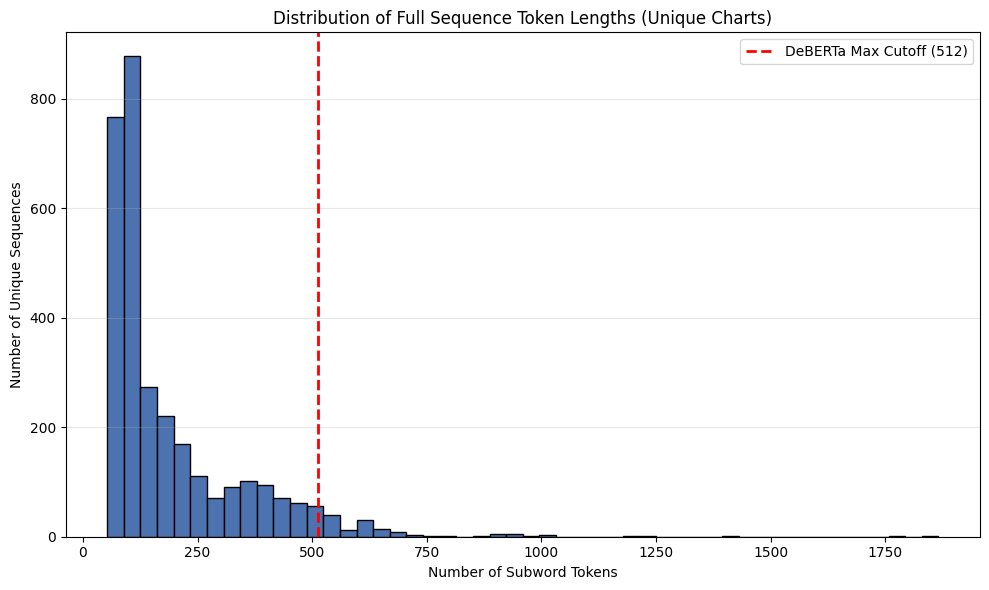

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from transformers import AutoTokenizer

# Fix 1: Load the correct SentencePiece tokenizer for DeBERTa-v3
tokenizer = AutoTokenizer.from_pretrained("cross-encoder/nli-deberta-v3-large")

unique_lengths = []
seen_specs = set()

print("⏳ Tokenizing unique charts and full contexts...")
all_data = train_data + val_data + test_data + test2_data

for item in all_data:
    # Look for a stable chart ID, fallback to the spec string
    chart_id = str(item.get("image_path", item.get("chart_id", item.get("spec_str", "")))).strip()
    
    if chart_id not in seen_specs:
        seen_specs.add(chart_id)
        
        claim = str(item["claim"])
        desc = str(item.get("description", "")).strip()
        ctype = str(item.get("chart_type", "unknown"))
        spec = str(item.get("spec_str", "")).strip()
        
        prose_spec = spec_to_prose(spec)
        premise = f"Chart Description: {desc}. Chart Type: {ctype}. Data: {prose_spec}".strip()
        
        tokens = tokenizer(
            text=claim, 
            text_pair=premise, 
            truncation=False
        ) 
        unique_lengths.append(len(tokens["input_ids"]))

print(f"\nTotal Unique Charts Evaluated: {len(unique_lengths)}")
print(f"Max Sequence Tokens: {max(unique_lengths)}")
print(f"Average Sequence Tokens: {sum(unique_lengths)/len(unique_lengths):.0f}\n")

# 1. Mathematical Breakdown
bins = [0, 512, 1024, 2048, 4096, 10000]
labels = ["< 512 tokens", "512 - 1024 tokens", "1024 - 2048 tokens", "2048 - 4096 tokens", "> 4096 tokens"]

hist, _ = np.histogram(unique_lengths, bins=bins)

print("📊 Token Length Distribution (Full Model Inputs):")
print("-" * 55)
for label, count in zip(labels, hist):
    percentage = (count / len(unique_lengths)) * 100
    print(f"{label:>20}: {count:>5} sequences ({percentage:.1f}%)")

# 2. Visual Histogram
plt.figure(figsize=(10, 6))
plt.hist(unique_lengths, bins=50, color='#4C72B0', edgecolor='black')

plt.axvline(512, color='red', linestyle='dashed', linewidth=2, label='DeBERTa Max Cutoff (512)')

plt.title("Distribution of Full Sequence Token Lengths (Unique Charts)")
plt.xlabel("Number of Subword Tokens")
plt.ylabel("Number of Unique Sequences")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Cell 3 — Model Definition

In [11]:
import torch
import torch.nn as nn
from transformers import AutoModel
from torch.nn.utils.rnn import pad_sequence

class NLIVerifier(nn.Module):
    """
    Binary claim verifier built on a pre-trained NLI cross-encoder.

    Architecture
    ─────────────
    DeBERTa-v3-base (NLI pre-trained)
        └── [CLS] token representation  (768-dim)
            └── LayerNorm
            └── Dropout(0.1)
            └── Linear(768 → 384)  + GELU
            └── Dropout(0.1)
            └── Linear(384 → 1)    → raw logit

    The two-layer MLP is intentionally small — DeBERTa already does the heavy
    lifting.  A fat head would overfit on 7 k samples.

    The original 3-class NLI head weights are ignored (ignore_mismatched_sizes);
    only the encoder backbone is loaded.
    """
    def __init__(self, model_name: str = NLI_MODEL_NAME, dropout: float = 0.1):
        super().__init__()

        # Load the backbone — we only want the encoder, not the NLI head
        self.encoder = AutoModel.from_pretrained(
            model_name,
            ignore_mismatched_sizes=True,  # silences the 3-class head mismatch
        )
        hidden = self.encoder.config.hidden_size  # 768 for base models

        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, 1),
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )
        # DeBERTa returns last_hidden_state; index 0 = [CLS]
        cls_rep = outputs.last_hidden_state[:, 0, :]   # (B, 768)
        logits  = self.classifier(cls_rep)              # (B, 1)
        return logits.squeeze(-1)                       # (B,)


# ── Instantiate & cast ─────────────────────────────────────────────────────────
nli_model = NLIVerifier(NLI_MODEL_NAME)

SAFE_DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float32
nli_model  = nli_model.to(device=DEVICE, dtype=SAFE_DTYPE)

total_params     = sum(p.numel() for p in nli_model.parameters())
trainable_params = sum(p.numel() for p in nli_model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"Model dtype          : {SAFE_DTYPE}")

# ── CPU dry-run ────────────────────────────────────────────────────────────────
print("\nRunning CPU dry-run...")
_sample = next(iter(nli_train_loader))
_cpu_model = NLIVerifier(NLI_MODEL_NAME)   # fp32 on CPU for the test
with torch.no_grad():
    _out = _cpu_model(
        _sample["input_ids"],
        _sample["attention_mask"],
    )
print(f"✅ Dry-run passed — output shape: {_out.shape}, dtype: {_out.dtype}")
del _cpu_model, _out

Loading weights:   0%|          | 0/390 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: cross-encoder/nli-deberta-v3-large
Key                             | Status     |  | 
--------------------------------+------------+--+-
classifier.weight               | UNEXPECTED |  | 
classifier.bias                 | UNEXPECTED |  | 
deberta.embeddings.position_ids | UNEXPECTED |  | 
pooler.dense.weight             | UNEXPECTED |  | 
pooler.dense.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total parameters     : 434,539,521
Trainable parameters : 434,539,521
Model dtype          : torch.bfloat16

Running CPU dry-run...


Loading weights:   0%|          | 0/390 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: cross-encoder/nli-deberta-v3-large
Key                             | Status     |  | 
--------------------------------+------------+--+-
classifier.weight               | UNEXPECTED |  | 
classifier.bias                 | UNEXPECTED |  | 
deberta.embeddings.position_ids | UNEXPECTED |  | 
pooler.dense.weight             | UNEXPECTED |  | 
pooler.dense.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Dry-run passed — output shape: torch.Size([4]), dtype: torch.float32


## Cell 4 — Optimizer & Scheduler

In [12]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

def build_optimizer_and_scheduler(model, train_loader):
    """
    Differential learning rates:
      • Encoder layers    →  NLI_ENCODER_LR (1e-5)  — already well-trained, nudge gently
      • Classifier head   →  NLI_HEAD_LR    (5e-5)  — randomly initialised, needs faster steps

    Weight decay is disabled for biases and LayerNorm parameters following
    the standard BERT fine-tuning recipe.
    """
    no_decay = {"bias", "LayerNorm.weight", "LayerNorm.bias",
                "layer_norm.weight", "layer_norm.bias"}

    encoder_decay, encoder_nodecay = [], []
    head_decay,    head_nodecay    = [], []

    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        bucket    = encoder_nodecay if any(nd in name for nd in no_decay) else encoder_decay
        head_buck = head_nodecay    if any(nd in name for nd in no_decay) else head_decay

        if name.startswith("encoder"):
            bucket.append(param)
        else:
            head_buck.append(param)

    param_groups = [
        {"params": encoder_decay,   "lr": NLI_ENCODER_LR, "weight_decay": NLI_WEIGHT_DECAY},
        {"params": encoder_nodecay, "lr": NLI_ENCODER_LR, "weight_decay": 0.0},
        {"params": head_decay,      "lr": NLI_HEAD_LR,    "weight_decay": NLI_WEIGHT_DECAY},
        {"params": head_nodecay,    "lr": NLI_HEAD_LR,    "weight_decay": 0.0},
    ]

    optimizer = AdamW(param_groups)

    total_steps  = (len(train_loader) // NLI_ACCUMULATION_STEPS) * NLI_EPOCHS
    warmup_steps = int(NLI_WARMUP_RATIO * total_steps)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps,
    )

    print(f"Total optimiser steps : {total_steps}")
    print(f"Warmup steps          : {warmup_steps}  ({NLI_WARMUP_RATIO*100:.0f}%)")
    print(f"Encoder param tensors : {len(encoder_decay) + len(encoder_nodecay)}")
    print(f"Head    param tensors : {len(head_decay)    + len(head_nodecay)}")
    return optimizer, scheduler


nli_optimizer, nli_scheduler = build_optimizer_and_scheduler(nli_model, nli_train_loader)

# ── NEW: Label Smoothing Loss ─────────────────────────────────────────────────
class LabelSmoothingBCE(nn.Module):
    def __init__(self, smoothing=0.05, pos_weight=None):
        super().__init__()
        self.smoothing = smoothing
        self.bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        
    def forward(self, logits, targets):
        # Smooth targets: 1.0 -> 0.95, 0.0 -> 0.05
        targets_smooth = targets * (1.0 - self.smoothing) + 0.5 * self.smoothing
        return self.bce(logits, targets_smooth)

nli_criterion = LabelSmoothingBCE(
    smoothing=NLI_LABEL_SMOOTHING,
    pos_weight=torch.tensor([pos_weight_value], dtype=torch.float32).to(DEVICE)
)

Total optimiser steps : 1185
Warmup steps          : 71  (6%)
Encoder param tensors : 390
Head    param tensors : 6


## Cell 5 — Training Loop

In [13]:
import os
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score

# ── Evaluation helper ──────────────────────────────────────────────────────────
def nli_evaluate(model, dataloader, criterion, device):
    """Returns (avg_loss, accuracy, macro_f1)."""
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []

    with torch.no_grad():
        for batch in dataloader:
            ids    = batch["input_ids"].to(device)
            mask   = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            logits = model(ids, mask)
            loss   = criterion(logits.to(torch.float32), labels.to(torch.float32))
            total_loss += loss.item()

            preds = (torch.sigmoid(logits) >= 0.5).long().cpu().tolist()
            all_preds.extend(preds)
            all_labels.extend(labels.long().cpu().tolist())

    avg_loss = total_loss / len(dataloader)
    acc      = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, acc, f1


# ── Training loop ──────────────────────────────────────────────────────────────
print(f"🚀 Starting NLI Verifier training — {NLI_EPOCHS} epochs on {DEVICE}")
print(f"   Physical batch {NLI_BATCH_SIZE} × {NLI_ACCUMULATION_STEPS} accum = effective {NLI_EFFECTIVE_BATCH}")
print("─" * 70)

best_val_f1       = 0.0
best_epoch        = 0
history           = []          # list of dicts for post-training analysis

nli_optimizer.zero_grad()

for epoch in range(NLI_EPOCHS):
    nli_model.train()
    total_train_loss = 0.0
    n_optimizer_steps = 0

    bar = tqdm(nli_train_loader, desc=f"Epoch {epoch+1}/{NLI_EPOCHS}", dynamic_ncols=True)

    for step, batch in enumerate(bar):
        ids    = batch["input_ids"].to(DEVICE)
        mask   = batch["attention_mask"].to(DEVICE)
        labels = batch["label"].to(DEVICE)

        logits = nli_model(ids, mask)
        loss   = nli_criterion(logits, labels.to(logits.dtype))

        # Scale loss for gradient accumulation
        (loss / NLI_ACCUMULATION_STEPS).backward()
        total_train_loss += loss.item()

        is_accum_step = ((step + 1) % NLI_ACCUMULATION_STEPS == 0)
        is_last_step  = ((step + 1) == len(nli_train_loader))

        if is_accum_step or is_last_step:
            torch.nn.utils.clip_grad_norm_(nli_model.parameters(), NLI_MAX_GRAD_NORM)
            nli_optimizer.step()
            nli_scheduler.step()
            nli_optimizer.zero_grad()
            n_optimizer_steps += 1

        bar.set_postfix(loss=f"{loss.item():.4f}",
                        lr=f"{nli_scheduler.get_last_lr()[0]:.2e}")

    # ── End-of-epoch metrics ───────────────────────────────────────────────────
    avg_train_loss = total_train_loss / len(nli_train_loader)
    val_loss, val_acc, val_f1 = nli_evaluate(nli_model, nli_val_loader, nli_criterion, DEVICE)

    history.append({
        "epoch": epoch + 1,
        "train_loss": avg_train_loss,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_f1": val_f1,
    })

    marker = ""
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch  = epoch + 1
        torch.save(nli_model.state_dict(), NLI_BEST_MODEL_PATH)
        marker = "  💾 saved"

    print(
        f"Epoch {epoch+1:2d}/{NLI_EPOCHS} "
        f"| train_loss {avg_train_loss:.4f} "
        f"| val_loss {val_loss:.4f} "
        f"| val_acc {val_acc*100:.2f}% "
        f"| val_f1 {val_f1*100:.2f}%"
        f"{marker}"
    )

print("─" * 70)
print(f"✅ Training complete.  Best model: epoch {best_epoch}, val F1 = {best_val_f1*100:.2f}%")
print(f"   Checkpoint saved to: {NLI_BEST_MODEL_PATH}")

🚀 Starting NLI Verifier training — 5 epochs on cuda
   Physical batch 4 × 8 accum = effective 32
──────────────────────────────────────────────────────────────────────


Epoch 1/5: 100%|██████████| 1902/1902 [04:37<00:00,  6.84it/s, loss=0.4629, lr=2.55e-05]


Epoch  1/5 | train_loss 0.6251 | val_loss 0.5571 | val_acc 72.51% | val_f1 72.39%  💾 saved


Epoch 2/5: 100%|██████████| 1902/1902 [04:38<00:00,  6.84it/s, loss=0.2598, lr=1.91e-05]


Epoch  2/5 | train_loss 0.5204 | val_loss 0.5379 | val_acc 73.35% | val_f1 73.11%  💾 saved


...

Epoch  3/5 | train_loss 0.4719 | val_loss 0.5439 | val_acc 74.19% | val_f1 74.11%  💾 saved


Epoch 4/5: 100%|██████████| 1902/1902 [04:37<00:00,  6.87it/s, loss=0.3770, lr=6.27e-06]


Epoch  4/5 | train_loss 0.4481 | val_loss 0.5510 | val_acc 73.66% | val_f1 73.55%


Epoch 5/5: 100%|██████████| 1902/1902 [04:38<00:00,  6.83it/s, loss=0.1855, lr=0.00e+00]


Epoch  5/5 | train_loss 0.4393 | val_loss 0.5522 | val_acc 73.98% | val_f1 73.87%
──────────────────────────────────────────────────────────────────────
✅ Training complete.  Best model: epoch 3, val F1 = 74.11%
   Checkpoint saved to: best_nli_verifier.pt


Test-Time Ensembling Evaluation

In [ ]:
import torch

# Paths to your trained checkpoints
ENSEMBLE_PATHS = ["model_seed1.pt", "model_seed2.pt", "model_seed3.pt"]

def run_ensemble_classification(model, dataloader, device, checkpoints):
    print(f"Evaluating ensemble of {len(checkpoints)} models...")
    all_labels = []
    all_ensemble_probs = []
    
    # Collect probabilities from each model
    for ckpt_path in checkpoints:
        model.load_state_dict(torch.load(ckpt_path, map_location=device))
        model.eval()
        
        model_probs = []
        labels_collected = False
        
        with torch.no_grad():
            for batch in dataloader:
                ids  = batch["input_ids"].to(device)
                mask = batch["attention_mask"].to(device)
                
                logits = model(ids, mask)
                probs = torch.sigmoid(logits).cpu().numpy()
                model_probs.extend(probs)
                
                if not labels_collected:
                    all_labels.extend(batch["label"].cpu().numpy())
                    
        labels_collected = True
        all_ensemble_probs.append(model_probs)
    
    # Average the probabilities across all models
    avg_probs = np.mean(all_ensemble_probs, axis=0)
    final_preds = (avg_probs >= 0.5).astype(int)
    
    acc = accuracy_score(all_labels, final_preds) * 100
    f1  = f1_score(all_labels, final_preds, average="macro", zero_division=0) * 100
    
    return acc, f1

# Run on test set
ens_acc, ens_f1 = run_ensemble_classification(nli_model, nli_test_loader, DEVICE, ENSEMBLE_PATHS)
print(f"Ensemble Test 1 -> Acc: {ens_acc:.1f}% | Macro-F1: {ens_f1:.1f}")

## Cell 6 — Classification Evaluation (Acc / F1)

In [23]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, classification_report
from tqdm import tqdm

# ── Load best checkpoint ───────────────────────────────────────────────────────
nli_model.load_state_dict(torch.load(NLI_BEST_MODEL_PATH, map_location=DEVICE))
nli_model.eval()
print(f"✅ Loaded best checkpoint from '{NLI_BEST_MODEL_PATH}' (epoch {best_epoch})")

# ── Per-set classification helper ─────────────────────────────────────────────
def run_classification(model, dataloader, device, desc="Evaluating"):
    """
    Returns (accuracy %, macro_f1 %, preds list, labels list).
    Also captures chart_type and reasoning_type for the breakdown matrix.
    """
    all_preds, all_labels = [], []
    all_chart_types, all_reasoning_types = [], []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc=desc):
            ids    = batch["input_ids"].to(device)
            mask   = batch["attention_mask"].to(device)
            labels = batch["label"].cpu().tolist()

            logits = model(ids, mask)
            preds  = (torch.sigmoid(logits) >= 0.5).long().cpu().tolist()

            all_preds.extend(preds)
            all_labels.extend([int(l) for l in labels])
            all_chart_types.extend(batch["chart_type"])
            all_reasoning_types.extend(batch["reasoning_type"])

    acc = accuracy_score(all_labels, all_preds) * 100
    f1  = f1_score(all_labels, all_preds, average="macro", zero_division=0) * 100
    return acc, f1, all_preds, all_labels, all_chart_types, all_reasoning_types


# ── Run on both test sets ──────────────────────────────────────────────────────
t1_acc, t1_f1, t1_preds, t1_labels, t1_ctypes, t1_rtypes = run_classification(
    nli_model, nli_test_loader,  DEVICE, desc="Test 1"
)
t2_acc, t2_f1, t2_preds, t2_labels, t2_ctypes, t2_rtypes = run_classification(
    nli_model, nli_test2_loader, DEVICE, desc="Test 2"
)
avg_acc = (t1_acc + t2_acc) / 2.0

print(f"\n{'─'*50}")
print(f"Test 1  →  Acc: {t1_acc:.1f}%   Macro-F1: {t1_f1:.1f}")
print(f"Test 2  →  Acc: {t2_acc:.1f}%   Macro-F1: {t2_f1:.1f}")
print(f"Average →  Acc: {avg_acc:.1f}%")

# ── Per-class breakdown (Test 1) ───────────────────────────────────────────────
print(f"\nTest 1 — Per-class report:")
print(classification_report(t1_labels, t1_preds, target_names=["REFUTED", "SUPPORTED"], zero_division=0))

# ── Fine-grained breakdown: chart type ────────────────────────────────────────
# One record per SAMPLE (not per reasoning_type) so counts are correct and
# samples with reasoning_type='unknown' are not silently dropped.
print("Fine-grained: performance by chart type (Test 1)")
print("─" * 50)
ctype_records = []
for pred, label, ctype in zip(t1_preds, t1_labels, t1_ctypes):
    ctype_records.append({
        "chart_type": str(ctype).strip() or "unknown",
        "correct":    int(pred == label),
    })

df_ctype = pd.DataFrame(ctype_records)
topology_df = (
    df_ctype.groupby("chart_type")["correct"]
    .agg(Accuracy="mean", Count="count")
    .assign(Accuracy=lambda x: (x["Accuracy"] * 100).round(1).astype(str) + "%")
    .sort_values("Count", ascending=False)
)
print(topology_df.to_string())
print(f"  Total samples accounted for: {df_ctype['correct'].count()} / {len(t1_preds)}")

# ── Fine-grained breakdown: reasoning type ────────────────────────────────────
# One record per (sample × reasoning_type) — a sample with multiple types
# legitimately contributes to each type's bucket.
# Samples whose ONLY type is 'unknown' are excluded from this table only.
print("\nFine-grained: performance by reasoning type (Test 1)")
print("─" * 50)
rt_records = []
for pred, label, ctype, rtypes in zip(t1_preds, t1_labels, t1_ctypes, t1_rtypes):
    r_list = [rtypes] if isinstance(rtypes, str) else list(rtypes)
    for rt in r_list:
        if str(rt).strip().lower() == "unknown":
            continue
        rt_records.append({
            "chart_type":    str(ctype).strip() or "unknown",
            "reasoning_type": str(rt).strip(),
            "correct":        int(pred == label),
        })

df_rt = pd.DataFrame(rt_records)
reasoning_df = (
    df_rt.groupby("reasoning_type")["correct"]
    .agg(Accuracy="mean", Count="count")
    .assign(Accuracy=lambda x: (x["Accuracy"] * 100).round(1).astype(str) + "%")
    .sort_values("Count", ascending=False)
)
print(reasoning_df.to_string())

✅ Loaded best checkpoint from 'best_nli_verifier.pt' (epoch 3)


Test 2: 100%|██████████| 246/246 [00:10<00:00, 23.66it/s]


──────────────────────────────────────────────────
Test 1  →  Acc: 75.3%   Macro-F1: 75.3
Test 2  →  Acc: 74.8%   Macro-F1: 74.8
Average →  Acc: 75.1%

Test 1 — Per-class report:
              precision    recall  f1-score   support

     REFUTED       0.74      0.74      0.74       452
   SUPPORTED       0.76      0.76      0.76       487

    accuracy                           0.75       939
   macro avg       0.75      0.75      0.75       939
weighted avg       0.75      0.75      0.75       939

Fine-grained: performance by chart type (Test 1)
──────────────────────────────────────────────────
                    Accuracy  Count
chart_type                         
pie_chart              77.2%    382
line_chart             68.9%    244
barchart_vertical      78.8%    212
barchart_horizontal    81.7%     71
histogram              61.9%     21
unknown                66.7%      3
area                   50.0%      2
bar+line               50.0%      2
scatter_plot          100.0%     

## Cell 7 — Rationale Generation + NLP Metrics

The NLI model is a classifier — it does not auto-regressively generate text.  
We synthesise rationales the same way the original cross-attention notebook does:
1. Use the model's prediction (SUPPORTED / REFUTED).
2. Extract the top-k spec tokens with the highest attention weight from the final encoder layer.
3. Trace those tokens back to their JSON paths to build a human-readable evidence list.
4. Pass claim + evidence + prediction to **QwenVL** (your Stage-1 model) to generate a fluent rationale.

This keeps the rationale generation consistent with the pipeline you already have.

In [18]:
!pip install bert_score
!pip install rouge_score


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24935 sha256=548695e65a6d7b3f4961dfb463e49a69c11873798a441052640d48119e29ce35
  Stored in directory: /root/.cache/pip/wheels/1e/19/43/8a442dc83660ca25e163e1bd1f89919284ab0d0c1475475148
Successfully built rouge_score

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [16]:
# Run this to see what fields your test samples actually have
print("Keys in test_data[0]:", list(test_data[0].keys()))
print("Keys in combined_raw[0]:", list((test_data + test2_data)[0].keys()))

# Also check the raw JSON before load_and_prep_data processes it
with open("test_1_w_spec.json", "r") as f:
    raw = json.load(f)
print("\nRaw JSON keys:", list(raw[0].keys()))
print("\nSample explanation-like fields:")
for k, v in raw[0].items():
    if isinstance(v, str) and len(v) > 30:
        print(f"  '{k}': {v[:80]}...")

Keys in test_data[0]: ['claim', 'description', 'spec_str', 'chart_type', 'reasoning_type', 'label', 'explanation']
Keys in combined_raw[0]: ['claim', 'description', 'spec_str', 'chart_type', 'reasoning_type', 'label', 'explanation']

Raw JSON keys: ['local_image_path', 'original_url', 'claim', 'label', 'explanation', 'chart_type', 'reasoning_type', 'title_description', 'extended_spec']

Sample explanation-like fields:
  'local_image_path': local_images/TOILET_MEAL_SOCIAL_RESERCH.jpg...
  'original_url': https://chartfc.s3.amazonaws.com/TOILET_MEAL_SOCIAL_RESERCH.jpg...
  'claim': Only 12.08% of respondents have eaten in a public bathroom....
  'explanation': The chart shows that out of the 2459 valid responses in the survey, only 12.08% ...


In [19]:
import json
import numpy as np
import nltk
import torch
from tqdm import tqdm
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.tokenize import word_tokenize
from rouge_score import rouge_scorer
from torch.utils.data import ConcatDataset
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

print("Loading Flan-T5 for rationale synthesis...")
# Explicitly load the model and tokenizer to bypass pipeline task errors
tokenizer_t5 = AutoTokenizer.from_pretrained("google/flan-t5-base")
model_t5 = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-base").to(DEVICE)
model_t5.eval()

nltk.download("punkt",     quiet=True)
nltk.download("punkt_tab", quiet=True) 
nltk.download("wordnet",   quiet=True)

# ── Attention extraction helper ────────────────────────────────────────────────
class NLIVerifierWithAttention(NLIVerifier):
    """Same as NLIVerifier but optionally returns encoder attention weights."""
    def forward(self, input_ids, attention_mask, return_attentions=False):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_attentions=return_attentions,
        )
        cls_rep = outputs.last_hidden_state[:, 0, :]
        logits  = self.classifier(cls_rep).squeeze(-1)
        if return_attentions:
            # Stack all layer attentions: tuple of (B, heads, seq, seq)
            # Mean over heads and layers → (B, seq, seq)
            stacked = torch.stack(outputs.attentions, dim=0)  # (L, B, H, S, S)
            mean_attn = stacked.mean(dim=0).mean(dim=1)        # (B, S, S)
            return logits, mean_attn
        return logits


# Re-load weights into the attention-aware wrapper
nli_model_attn = NLIVerifierWithAttention(NLI_MODEL_NAME)
nli_model_attn.load_state_dict(torch.load(NLI_BEST_MODEL_PATH, map_location="cpu"))
nli_model_attn = nli_model_attn.to(DEVICE, dtype=SAFE_DTYPE)
nli_model_attn.eval()
print("✅ Attention-aware wrapper loaded.")


# ── Sentence-to-JSON-path tracer ───────────────────────────────────────────────
def extract_attended_sentence(premise_str, input_ids_1d, attn_row, tokenizer):
    """
    Maps the highest-attended DeBERTa tokens back to their parent sentence.

    Fixes over previous version:
      1. DATA_PREFIXES filter: skips 'Chart Description' and header sentences,
         only scores Series/Comparison/Ranking/Axis/Trend lines
      2. Float-safe splitting: splits on ". " (period + space) not bare "."
         so "0.1 kg" never splits into ["0", "1 kg"]
      3. Token length guard: ignores 1-char tokens to prevent false matches
    """
    tokens  = tokenizer.convert_ids_to_tokens(input_ids_1d.tolist())
    attn_np = attn_row.float().cpu().numpy()

    sep_indices = [i for i, t in enumerate(tokens) if t in ("[SEP]", "</s>")]
    if len(sep_indices) < 2:
        return "No specific data found."

    premise_start  = sep_indices[0] + 1
    premise_end    = sep_indices[1]
    premise_tokens = tokens[premise_start:premise_end]
    premise_attn   = attn_np[premise_start:premise_end]

    if not premise_tokens:
        return "No specific data found."

    premise_decoded = [
        tokenizer.convert_tokens_to_string([t]).strip()
        for t in premise_tokens
    ]

    # Fix 2: split on ". " to avoid splitting on decimal points
    import re as _re
    raw_sentences = _re.split(r'\. ', premise_str)
    sentences = [s.strip() for s in raw_sentences if s.strip()]
    if not sentences:
        return "No specific data found."

    # Fix 1: prefer data sentences over description/header sentences
    DATA_PREFIXES = ("series", "comparison", "ranking", "axis", "trend",
                     "min=", "max=", "categories")

    def is_data_sentence(s):
        return any(s.lower().startswith(p) for p in DATA_PREFIXES)

    data_sentences = [s for s in sentences if is_data_sentence(s)]
    candidates     = data_sentences if data_sentences else sentences

    best_sentence = candidates[0]
    best_score    = -1.0

    for sentence in candidates:
        sent_lower   = sentence.lower()
        token_scores = [
            attn for tok_str, attn in zip(premise_decoded, premise_attn)
            if tok_str and len(tok_str) > 1 and tok_str.lower() in sent_lower
        ]
        if token_scores:
            score = float(np.mean(token_scores))
            if score > best_score:
                best_score    = score
                best_sentence = sentence

    return best_sentence.strip() + "."


# ── Rationale generator ────────────────────────────────────────────────────────
def synthesise_lightweight_rationale(pred_label, evidence_sentence):
    """
    Constructs a fluent rationale using a deterministic template.
    0 parameters, 0 VLM calls.
    """
    verdict = "SUPPORTED" if pred_label == 1 else "REFUTED"
    
    if verdict == "SUPPORTED":
        rationale = f"The claim is {verdict}. The chart data confirms this, specifically: {evidence_sentence}"
    else:
        rationale = f"The claim is {verdict}. The chart data contradicts the statement, showing instead: {evidence_sentence}"
        
    return rationale

def synthesise_flant5_rationale(claim, pred_label, evidence_sentence):
    """
    Constructs a fluent rationale using Flan-T5 based on the extracted evidence.
    Prompt instructs the model to cite actual values and not restate the claim.
    """
    verdict = "supported" if pred_label == 1 else "refuted"

    prompt = (
        f"You are a chart fact-checking assistant. "
        f"The following claim has been verified as {verdict}.\n"
        f"Claim: {claim}\n"
        f"Chart evidence: {evidence_sentence}\n"
        f"Write one concise sentence explaining what the specific chart numbers show "
        f"and why the claim is therefore {verdict}. "
        f"Cite the actual values from the evidence. "
        f"Do NOT restate or paraphrase the claim.\n"
        f"Explanation:"
    )

    inputs = tokenizer_t5(prompt, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        outputs = model_t5.generate(
            **inputs,
            max_new_tokens=80,
            min_new_tokens=15,
            do_sample=False,
            num_beams=4,
            no_repeat_ngram_size=3,
            repetition_penalty=1.3,
        )

    return tokenizer_t5.decode(outputs[0], skip_special_tokens=True).strip()


# ── Rationale generation pass ──────────────────────────────────────────────────
print("Generating rationales over combined Test 1 + Test 2 ...")
combined_raw  = test_data + test2_data
combined_ds   = ConcatDataset([nli_test_dataset, nli_test2_dataset])

references, predictions = [], []

with torch.no_grad():
    for idx, sample in enumerate(tqdm(combined_ds, desc="Rationale generation")):
        gt_explanation = combined_raw[idx].get("explanation", "")
        
        if not gt_explanation:
            continue

        ids  = sample["input_ids"].unsqueeze(0).to(DEVICE)
        mask = sample["attention_mask"].unsqueeze(0).to(DEVICE)

        logits, mean_attn = nli_model_attn(ids, mask, return_attentions=True)
        pred_val = int((torch.sigmoid(logits) >= 0.5).long().item())

        # mean_attn is (B=1, S, S) — use CLS row (index 0)
        cls_attn = mean_attn[0, 0, :]   # (S,)

        # Reconstruct the exact prose premise fed into the model
        claim_text = combined_raw[idx]["claim"]
        ctype = str(combined_raw[idx].get("chart_type", "unknown"))
        desc = str(combined_raw[idx].get("description", "")).strip()
        # Assumes spec_to_prose is defined in memory from an earlier cell
        prose_spec = spec_to_prose(combined_raw[idx]["spec_str"])
        premise_str = f"Chart Description: {desc}. Chart Type: {ctype}. Data: {prose_spec}".strip()

        evidence_sentence = extract_attended_sentence(
            premise_str,
            sample["input_ids"],
            cls_attn,
            nli_tokenizer
        )

        rationale = synthesise_flant5_rationale(
            claim_text,
            pred_val,
            evidence_sentence
        )

        references.append(gt_explanation)
        predictions.append(rationale)

print(f"Generated {len(predictions)} rationales.")

# ── NLP Metrics ─────────────────────────────────────────────────────────────
if len(predictions) > 0:
    print("\nCalculating BLEU and ROUGE-L ...")
    rouge_sc   = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)
    smooth     = SmoothingFunction()
    bleu_list, rouge_list = [], []

    for ref, pred in zip(references, predictions):
        ref_tok  = word_tokenize(ref)
        pred_tok = word_tokenize(pred)
        bleu_list.append(sentence_bleu([ref_tok], pred_tok, smoothing_function=smooth.method1))
        rouge_list.append(rouge_sc.score(ref, pred)["rougeL"].fmeasure)

    nli_bleu  = np.mean(bleu_list)  * 100
    nli_rouge = np.mean(rouge_list) * 100
    print(f"  BLEU   : {nli_bleu:.1f}")
    print(f"  ROUGE-L: {nli_rouge:.1f}")

    # ── BERTScore ─────────────────────────────────────────────────────────────────
    print("Calculating BERTScore (this may take a minute) ...")
    from bert_score import score as calc_bert_score
    P, R, F1_bert = calc_bert_score(
        predictions, references, lang="en",
        verbose=False
    )
    nli_bertscore = F1_bert.mean().item() * 100
    print(f"  BERTScore F1: {nli_bertscore:.1f}")
else:
    print("\nNo ground-truth explanations found. Skipping NLP metrics (BLEU, ROUGE, BERTScore).")

print("\nSample Rationales:")
for i in range(5):
    print(f"Claim: {combined_raw[i]['claim']}")
    print(f"Rationale: {predictions[i]}\n")


Loading Flan-T5 for rationale synthesis...


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Loading weights:   0%|          | 0/390 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: cross-encoder/nli-deberta-v3-large
Key                             | Status     |  | 
--------------------------------+------------+--+-
classifier.weight               | UNEXPECTED |  | 
classifier.bias                 | UNEXPECTED |  | 
deberta.embeddings.position_ids | UNEXPECTED |  | 
pooler.dense.weight             | UNEXPECTED |  | 
pooler.dense.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  BERTScore F1: 88.9

Sample Rationales:
Claim: Only 12.08% of respondents have eaten in a public bathroom.
Rationale: Only 12.08% of respondents have eaten in a public bathroom. Chart evidence: Series 'Yes': [0.12].

Claim: In 2010 and 2011, number of citations to Q-Chem is in the lowest place in this chart.
Rationale: Q-Chem is in the lowest place in this chart. Chart evidence: Axis 'y_axis' range: -10 to 250.

Claim: The low importance category has the highest density in May 2014.
Rationale: The lowest density category has the highest density in May 2014. Chart evidence: Axis 'y_axis' range: 0 to 1.04.

Claim: Total cost has exceeded 55% overall.
Rationale: Total cost has exceeded 55% overall. Chart evidence: Series 'Expenditure': [0.43].

Claim: The second highest amount of recent wiktionary changes were done in Russian.
Rationale: The second highest amount of recent wiktionary changes were done in Russian. Chart evidence: Series 'ru': [0.03].



## Cell 8 — Final ChartCheck Comparison Matrix

In [20]:
import pandas as pd

# ── Baselines from the ChartCheck paper ───────────────────────────────────────
chartcheck_baselines = {
    "Model": [
        "DePlot-DeBERTa-class",
        "DePlot-FlanT5-finetune-multi",
        "MatCha-finetune-multi",
        "GPT4V (Zero-Shot)",
    ],
    "Task":        ["C",   "M",   "M",   "M"],
    "Test1_Acc":   [75.0,  65.7,  59.4,  73.8],
    "Test1_F1":    [75.0,  65.7,  59.1,  73.5],
    "Test2_Acc":   [72.5,  65.9,  61.1,  72.0],
    "Test2_F1":    [72.5,  65.8,  60.9,  71.3],
    "Avg_Acc":     [73.8,  65.8,  60.2,  72.9],
    "BLEU":        ["-",   17.3,  17.1,  10.0],
    "ROUGE-L":     ["-",   46.3,  37.3,  32.3],
    "BERTScore":   ["-",   91.5,  67.8,  89.1],
}

# ── Our result ────────────────────────────────────────────────────────────────
our_result = {
    "Model":      ["ChartSpec + NLI-DeBERTa (ours)"],
    "Task":       ["Pipeline"],
    "Test1_Acc":  [round(t1_acc,  1)],
    "Test1_F1":   [round(t1_f1,   1)],
    "Test2_Acc":  [round(t2_acc,  1)],
    "Test2_F1":   [round(t2_f1,   1)],
    "Avg_Acc":    [round(avg_acc, 1)],
    "BLEU":       [round(nli_bleu,       1)],
    "ROUGE-L":    [round(nli_rouge,      1)],
    "BERTScore":  [round(nli_bertscore,  1)],
}

df_base  = pd.DataFrame(chartcheck_baselines)
df_ours  = pd.DataFrame(our_result)
df_final = pd.concat([df_base, df_ours], ignore_index=True)

# ── Pretty print ──────────────────────────────────────────────────────────────
SEP = "=" * 115
print(f"\n{SEP}")
print("  CHARTCHECK EVALUATION MATRIX — NLI-DeBERTa Pipeline")
print(SEP)
print(df_final.to_string(index=False))
print(SEP)

# ── Delta vs best classification baseline (DePlot-DeBERTa, 73.8 avg) ──────────
best_baseline_avg = 73.8
delta = avg_acc - best_baseline_avg
direction = "above" if delta >= 0 else "below"
print(f"\n  Avg accuracy vs DePlot-DeBERTa baseline : {delta:+.1f}% ({direction})")

# ── Training history ──────────────────────────────────────────────────────────
print(f"\n  Training history:")
df_hist = pd.DataFrame(history)
df_hist["val_acc"] = (df_hist["val_acc"] * 100).round(2)
df_hist["val_f1"]  = (df_hist["val_f1"]  * 100).round(2)
df_hist["train_loss"] = df_hist["train_loss"].round(4)
df_hist["val_loss"]   = df_hist["val_loss"].round(4)
print(df_hist.to_string(index=False))


  CHARTCHECK EVALUATION MATRIX — NLI-DeBERTa Pipeline
                         Model     Task  Test1_Acc  Test1_F1  Test2_Acc  Test2_F1  Avg_Acc  BLEU ROUGE-L BERTScore
          DePlot-DeBERTa-class        C       75.0      75.0       72.5      72.5     73.8     -       -         -
  DePlot-FlanT5-finetune-multi        M       65.7      65.7       65.9      65.8     65.8  17.3    46.3      91.5
         MatCha-finetune-multi        M       59.4      59.1       61.1      60.9     60.2  17.1    37.3      67.8
             GPT4V (Zero-Shot)        M       73.8      73.5       72.0      71.3     72.9  10.0    32.3      89.1
ChartSpec + NLI-DeBERTa (ours) Pipeline       75.3      75.3       74.6      74.6     75.0  11.4    34.8      88.9

  Avg accuracy vs DePlot-DeBERTa baseline : +1.2% (above)

  Training history:
 epoch  train_loss  val_loss  val_acc  val_f1
     1      0.6251    0.5571    72.51   72.39
     2      0.5204    0.5379    73.35   73.11
     3      0.4719    0.5439    74.19